# Climate Data Analysis: NOAA Weather, CO2, and PDSI Features

This notebook analyzes climate features extracted from NOAA weather data, CO2 concentrations, and PDSI drought indicators.

## Sections
1. Imports and Settings
2. Configuration
3. Data Loading
4. NOAA Weather Features Analysis
5. CO2 Features Analysis
6. PDSI Features Analysis
7. Summary Statistics

## 1. Imports and Settings

In [72]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.util.path import DATA_DIR

print("✓ Imports successful")

✓ Imports successful


## 2. Configuration

In [73]:
# Crop selection
CROP = 'wheat'  # Options: 'corn', 'wheat', 'soybean'

# Plot settings
FIGURE_DPI = 100
FIGURE_SIZE_WIDE = (16, 6)
FIGURE_SIZE_TALL = (16, 10)
HIST_BINS = 40
HIST_ALPHA = 0.7

# Matplotlib settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = FIGURE_DPI
plt.rcParams['figure.figsize'] = FIGURE_SIZE_WIDE
plt.rcParams['font.size'] = 10
%matplotlib inline

# Seaborn settings
sns.set_palette('husl')

print(f"✓ Configuration set for crop: {CROP}")

✓ Configuration set for crop: wheat


## 3. Data Loading

In [74]:
data_path = DATA_DIR / 'ag' / f'{CROP}.csv'
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset: {CROP}.csv")
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Total columns: {len(df.columns)}")

Dataset: wheat.csv
Shape: (832, 146)
Date range: 2009-04-13 00:00:00 to 2025-03-17 00:00:00
Total columns: 146


In [75]:
# Identify feature groups

# NOAA weather features (TMAX, TMIN, AWND, SPI)
tmax_cols = [col for col in df.columns if 'TMAX' in col]
tmin_cols = [col for col in df.columns if 'TMIN' in col]
awnd_cols = [col for col in df.columns if 'AWND' in col]
spi_cols = [col for col in df.columns if 'SPI' in col]

noaa_weather_cols = tmax_cols + tmin_cols + awnd_cols + spi_cols

# CO2 features
co2_cols = [col for col in df.columns if 'co2' in col.lower()]

# PDSI features (drought/wetness indicators)
pdsi_cols = [col for col in df.columns if any(x in col for x in ['wet', 'dry', 'moderate'])]

print("\n" + "="*80)
print("FEATURE GROUPS")
print("="*80)
print(f"NOAA Weather Features: {len(noaa_weather_cols)}")
print(f"  - TMAX: {len(tmax_cols)}")
print(f"  - TMIN: {len(tmin_cols)}")
print(f"  - AWND: {len(awnd_cols)}")
print(f"  - SPI: {len(spi_cols)}")
print(f"\nCO2 Features: {len(co2_cols)}")
print(f"  {co2_cols}")
print(f"\nPDSI Features: {len(pdsi_cols)}")
print(f"  {pdsi_cols}")
print("="*80)


FEATURE GROUPS
NOAA Weather Features: 38
  - TMAX: 12
  - TMIN: 12
  - AWND: 12
  - SPI: 2

CO2 Features: 3
  ['zscore_co2', 'co2_monthly_mean', 'co2_seasonal_mean']

PDSI Features: 12
  ['moderate_wet', 'wet', 'moderate_dry', 'dry', 'monthly_moderate_wet', 'seasonal_moderate_wet', 'monthly_wet', 'seasonal_wet', 'monthly_moderate_dry', 'seasonal_moderate_dry', 'monthly_dry', 'seasonal_dry']


## 4. NOAA Weather Features Analysis

Analysis of temperature (TMAX/TMIN), wind speed (AWND), and precipitation (SPI) features extracted from NOAA weather data.

### 4.1 Helper Function

In [76]:
def plot_feature_distribution(df, features, title, color="steelblue", max_features=6):
    """Plot time series and histogram for features."""
    features_to_plot = features[:max_features]
    n_features = len(features_to_plot)
    
    fig, axes = plt.subplots(n_features, 2, figsize=(16, 4*n_features))
    if n_features == 1:
        axes = axes.reshape(1, -1)
    
    for idx, col in enumerate(features_to_plot):
        data = df[[col, 'date']].dropna()
        
        # Time series
        axes[idx, 0].plot(data['date'], data[col], linewidth=1, alpha=0.8, color=color)
        axes[idx, 0].set_title(f'{col}', fontsize=10, fontweight='bold')
        axes[idx, 0].set_xlabel('Date')
        axes[idx, 0].set_ylabel('Value')
        axes[idx, 0].grid(True, alpha=0.3)
        axes[idx, 0].tick_params(axis='x', rotation=45)
        
        # Histogram
        axes[idx, 1].hist(data[col], bins=HIST_BINS, edgecolor='black', alpha=HIST_ALPHA, color=color)
        axes[idx, 1].set_title('Distribution', fontsize=10, fontweight='bold')
        axes[idx, 1].set_xlabel('Value')
        axes[idx, 1].set_ylabel('Frequency')
        axes[idx, 1].grid(axis='y', alpha=0.3)
        
        # Statistics
        mean_val = data[col].mean()
        std_val = data[col].std()
        median_val = data[col].median()
        
        axes[idx, 1].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        axes[idx, 1].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        axes[idx, 1].legend(fontsize=8)
        
        stats_text = f"μ={mean_val:.2f}\nσ={std_val:.2f}\nmin={data[col].min():.2f}\nmax={data[col].max():.2f}"
        axes[idx, 1].text(0.98, 0.98, stats_text, transform=axes[idx, 1].transAxes,
                         verticalalignment='top', horizontalalignment='right',
                         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=8)
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.show()

print("✓ Helper function defined")

✓ Helper function defined


### 4.2 Maximum Temperature (TMAX) Features

Plotting 12 TMAX features (showing first 6)...
Features: ['TMAX_q3_value_in_planting', 'TMAX_q3_value_in_harvesting', 'TMAX_q4_value_in_planting', 'TMAX_q4_value_in_harvesting', 'monthly_TMAX_q3_value_in_planting', 'monthly_TMAX_q3_value_in_harvesting']


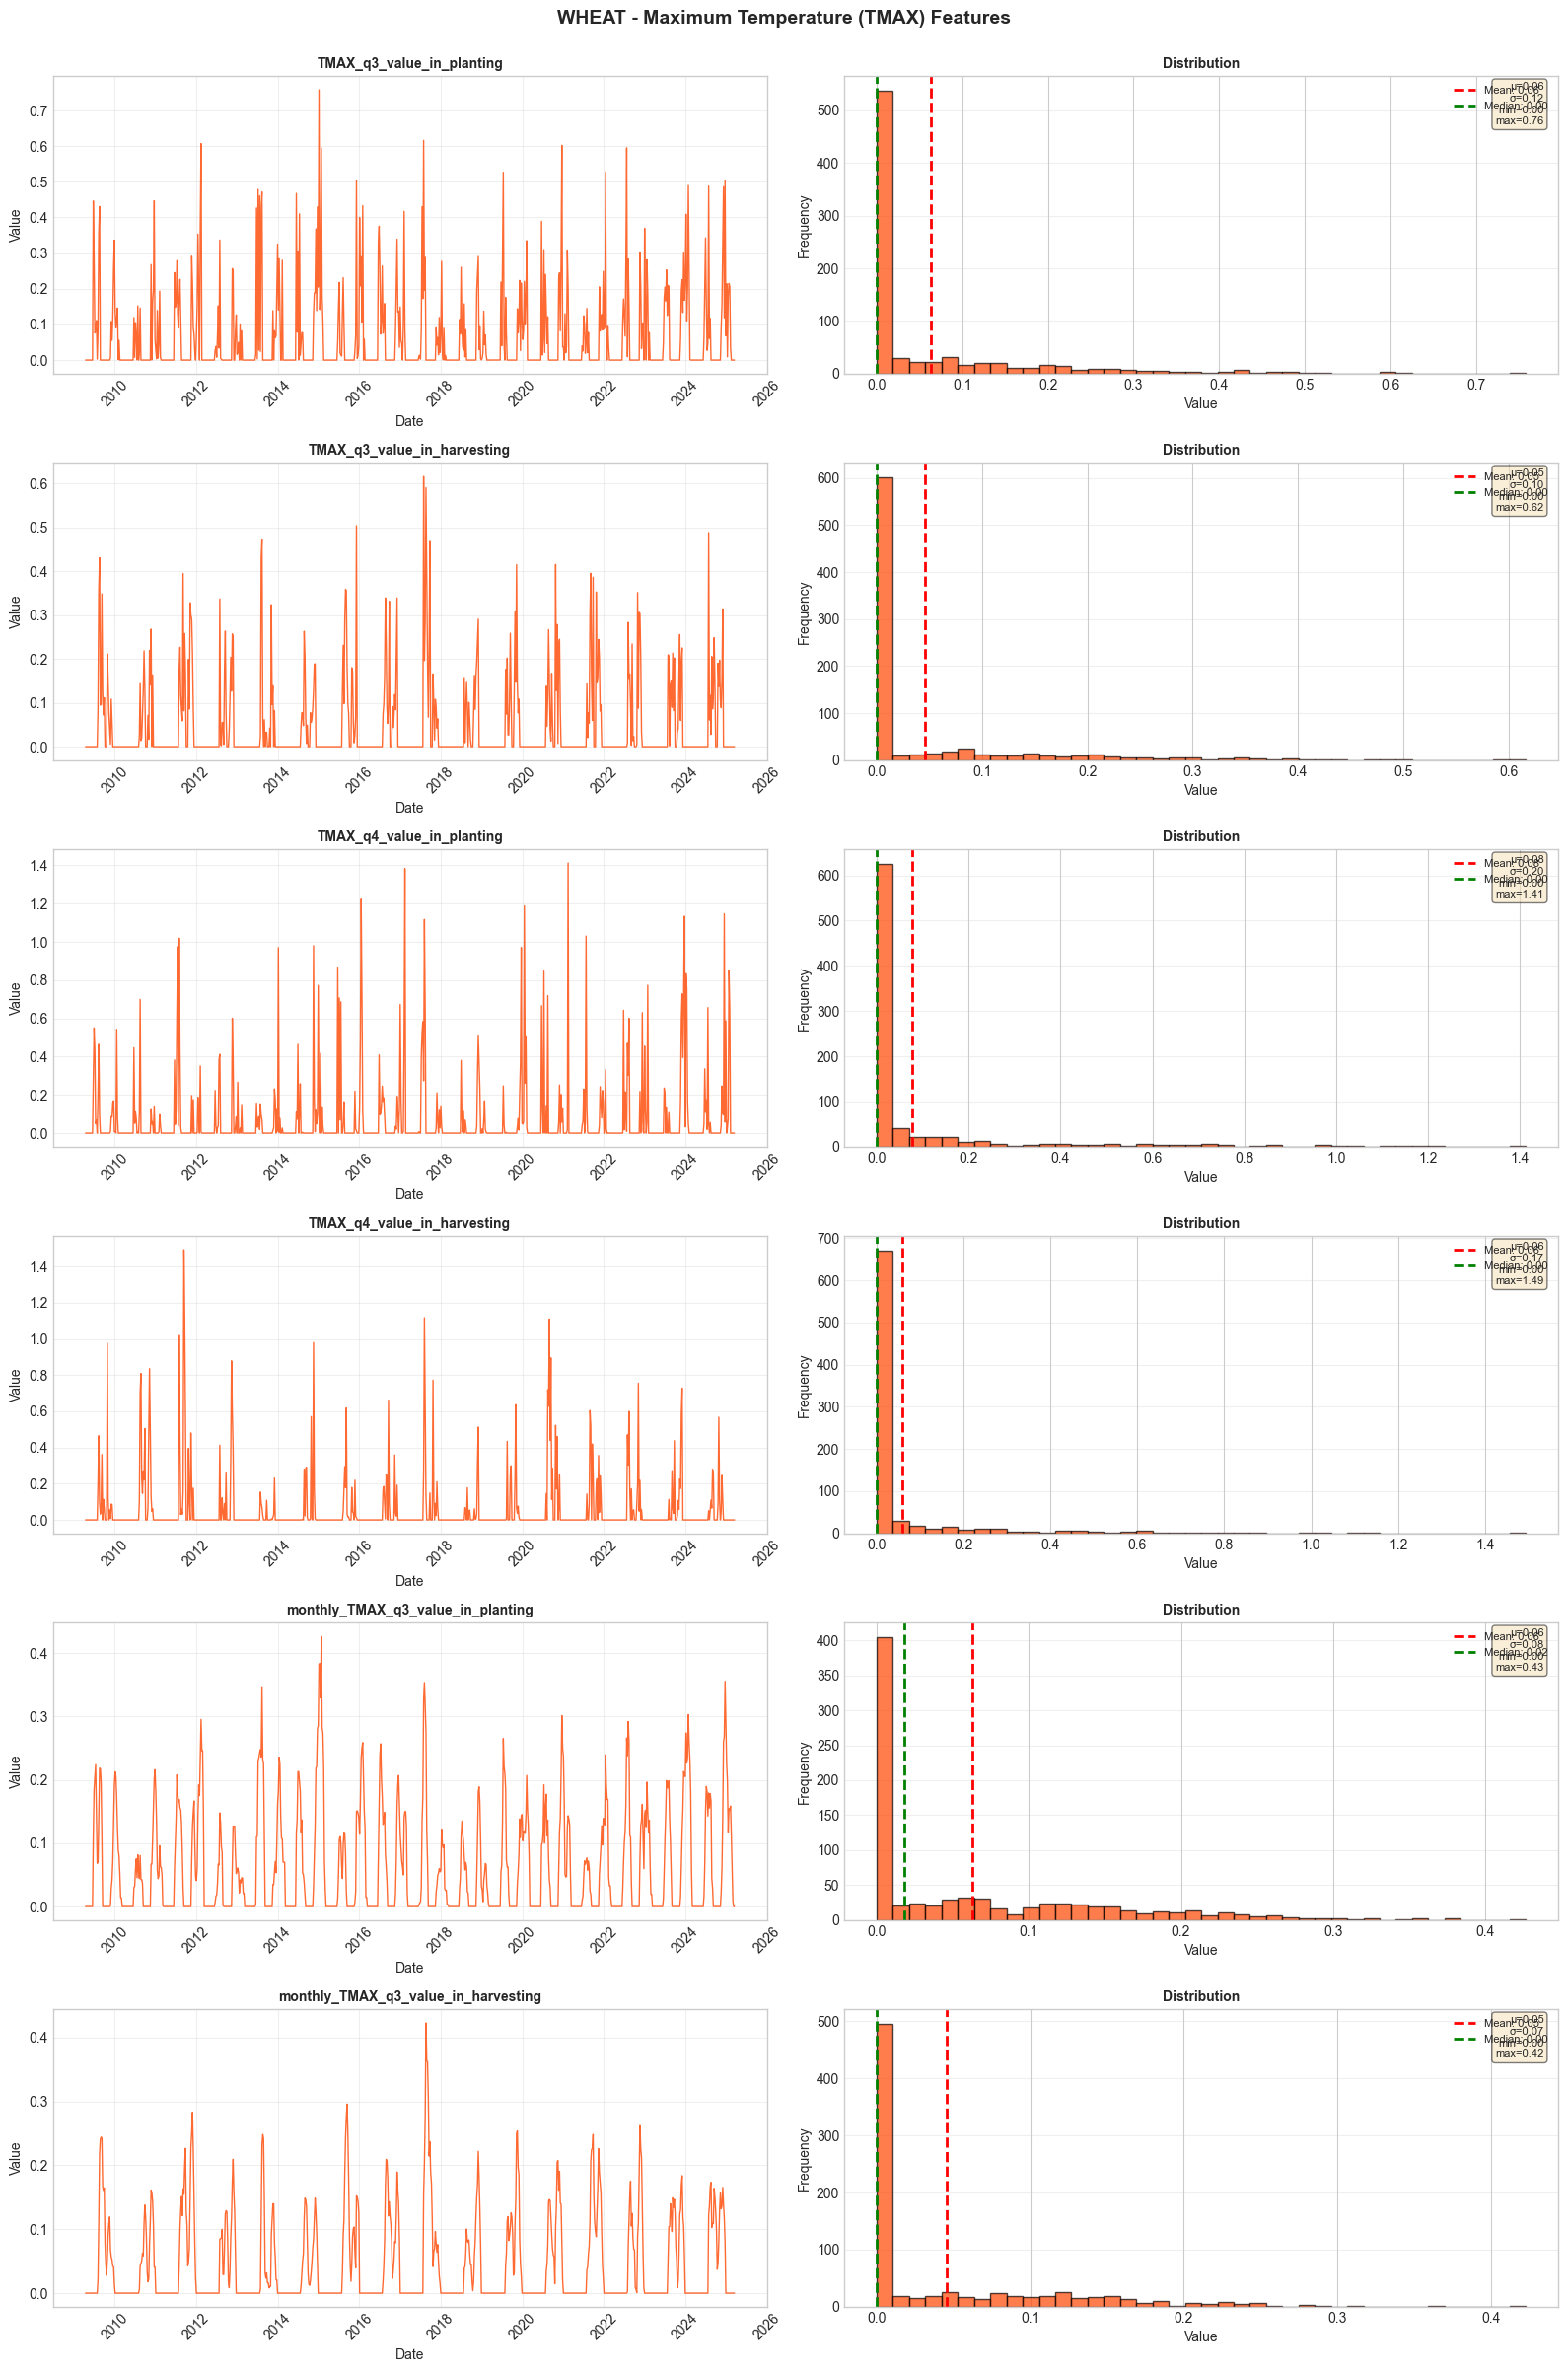

In [77]:
print(f"Plotting {len(tmax_cols)} TMAX features (showing first 6)...")
print(f"Features: {tmax_cols[:6]}")

plot_feature_distribution(
    df=df,
    features=tmax_cols,
    title=f'{CROP.upper()} - Maximum Temperature (TMAX) Features',
    color='orangered',
    max_features=6
)

### 4.3 Minimum Temperature (TMIN) Features

Plotting 12 TMIN features (showing first 6)...
Features: ['TMIN_q3_value_in_planting', 'TMIN_q3_value_in_harvesting', 'TMIN_q4_value_in_planting', 'TMIN_q4_value_in_harvesting', 'monthly_TMIN_q3_value_in_planting', 'monthly_TMIN_q3_value_in_harvesting']


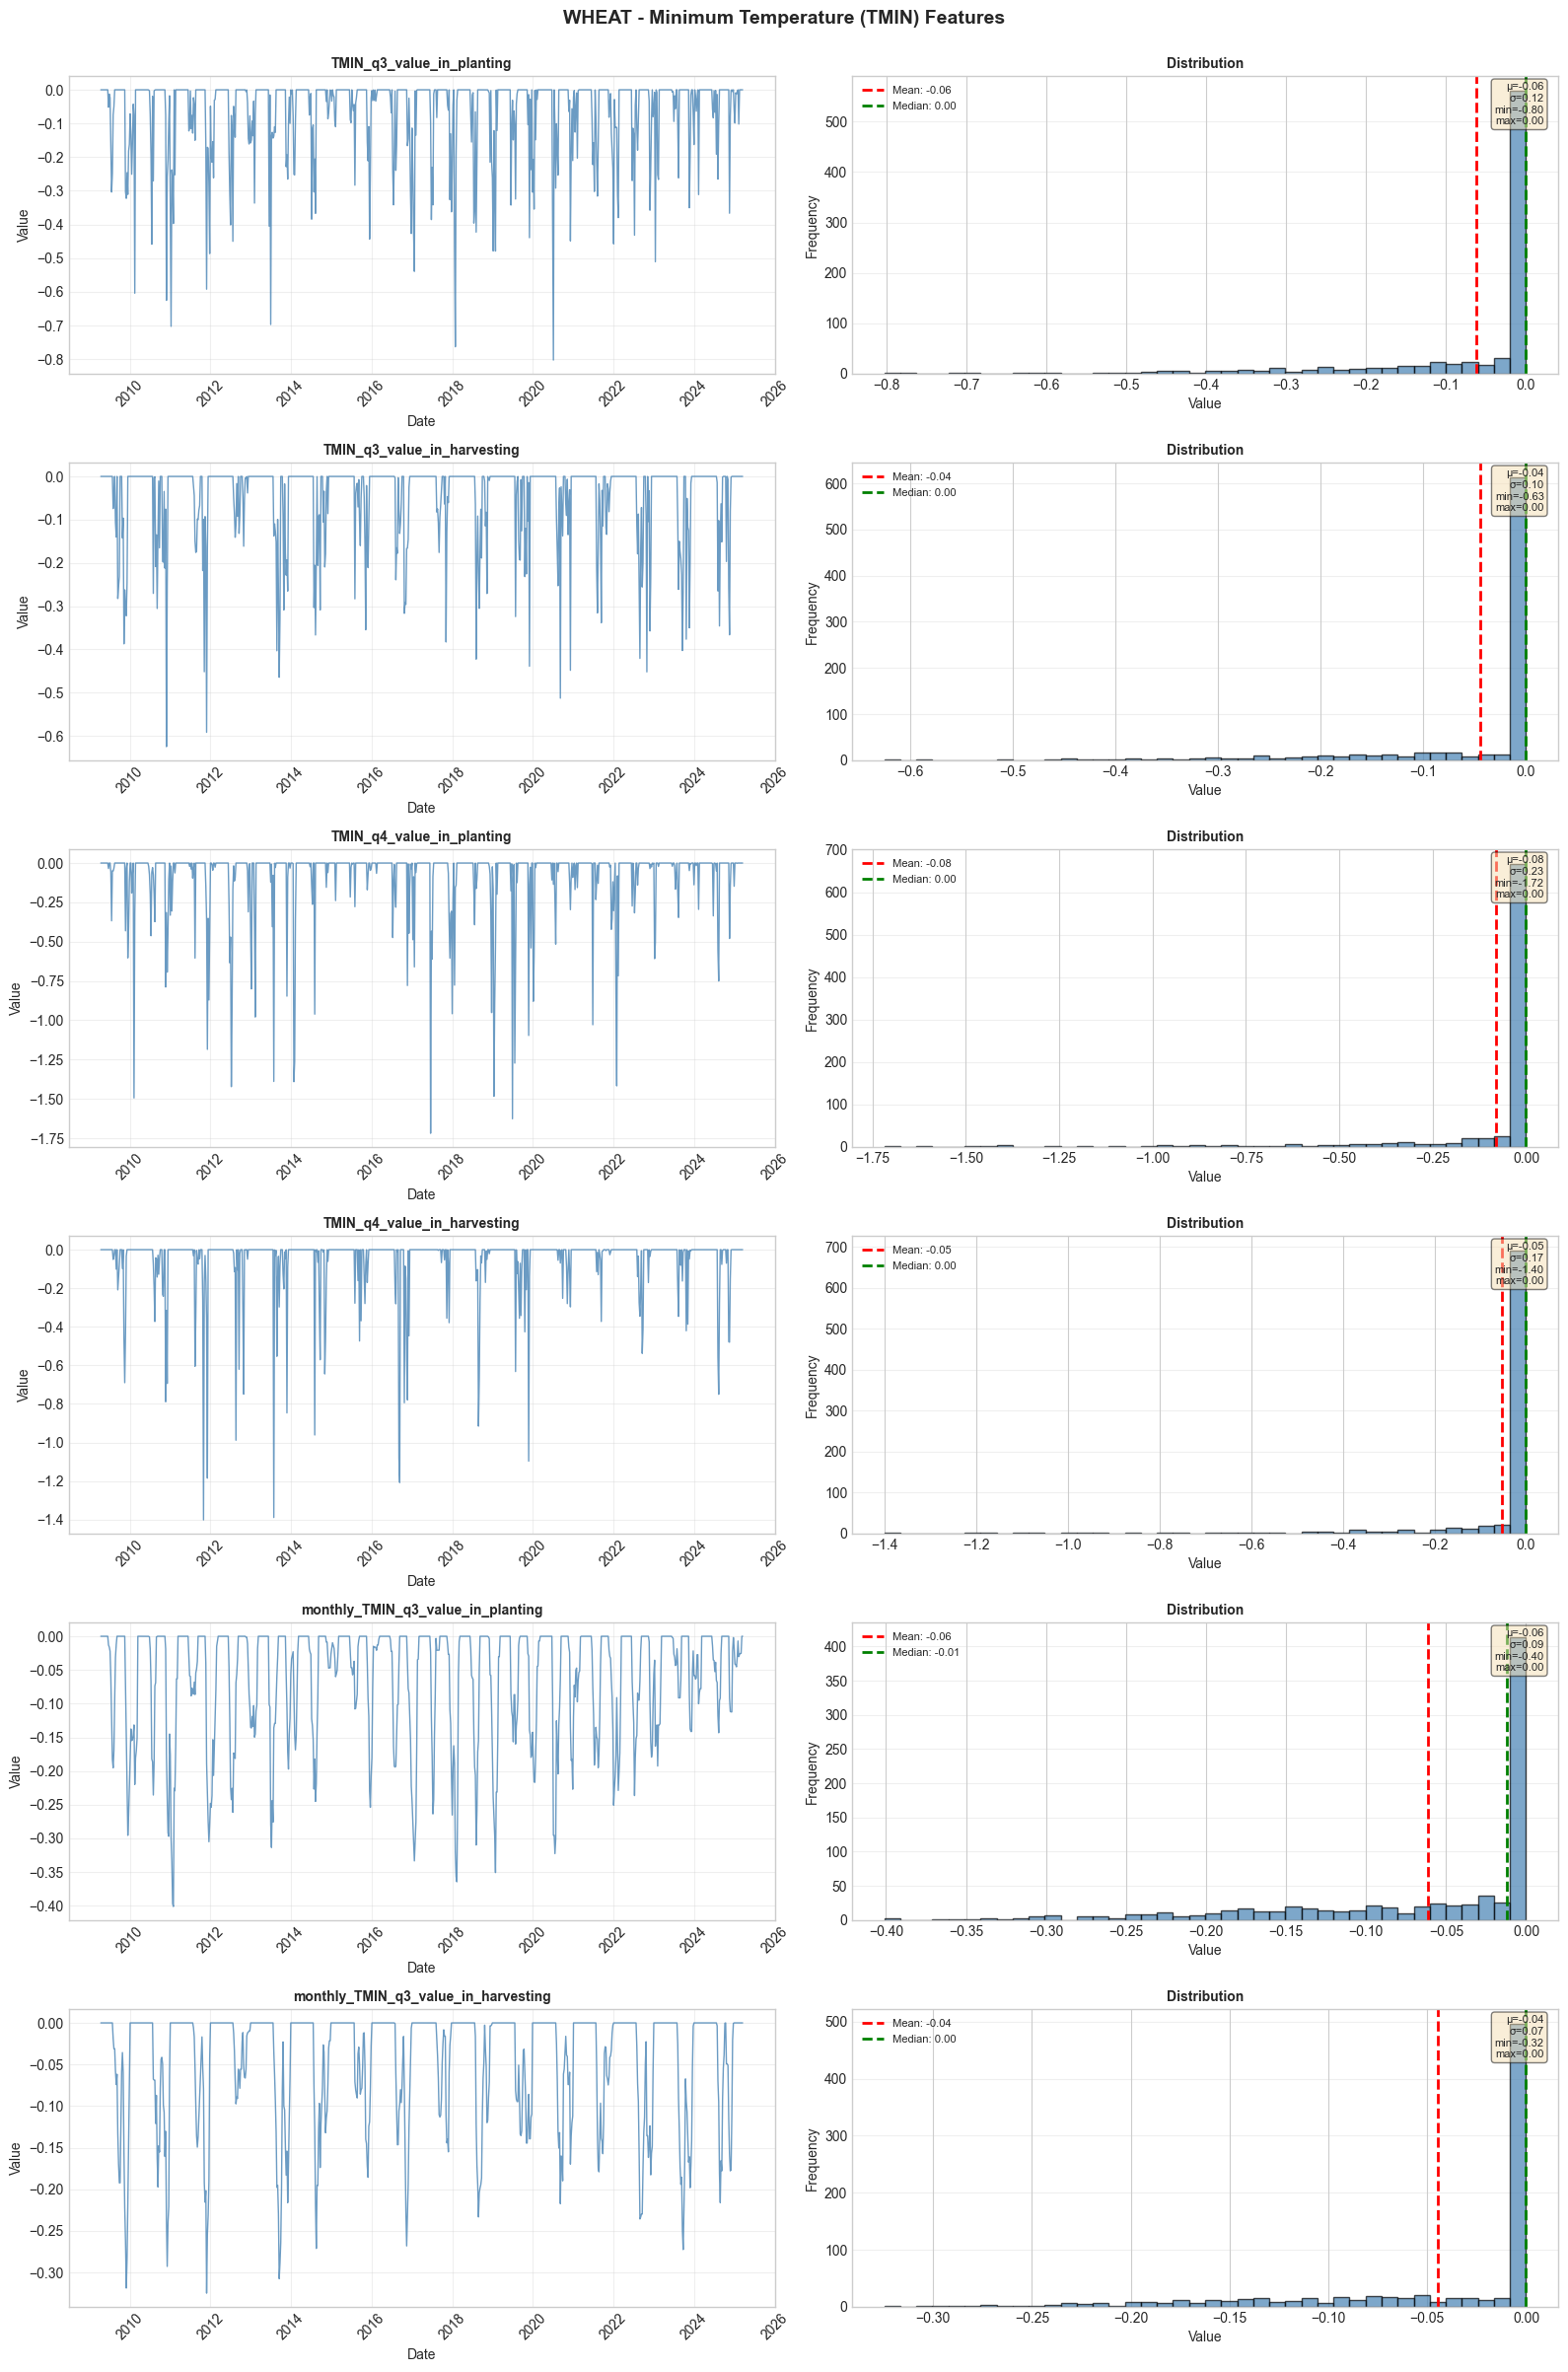

In [78]:
print(f"Plotting {len(tmin_cols)} TMIN features (showing first 6)...")
print(f"Features: {tmin_cols[:6]}")

plot_feature_distribution(
    df=df,
    features=tmin_cols,
    title=f'{CROP.upper()} - Minimum Temperature (TMIN) Features',
    color='steelblue',
    max_features=6
)

### 4.4 Wind Speed (AWND) Features

Plotting 12 AWND features (showing first 6)...
Features: ['AWND_q3_value_in_planting', 'AWND_q3_value_in_harvesting', 'AWND_q4_value_in_planting', 'AWND_q4_value_in_harvesting', 'monthly_AWND_q3_value_in_planting', 'monthly_AWND_q3_value_in_harvesting']


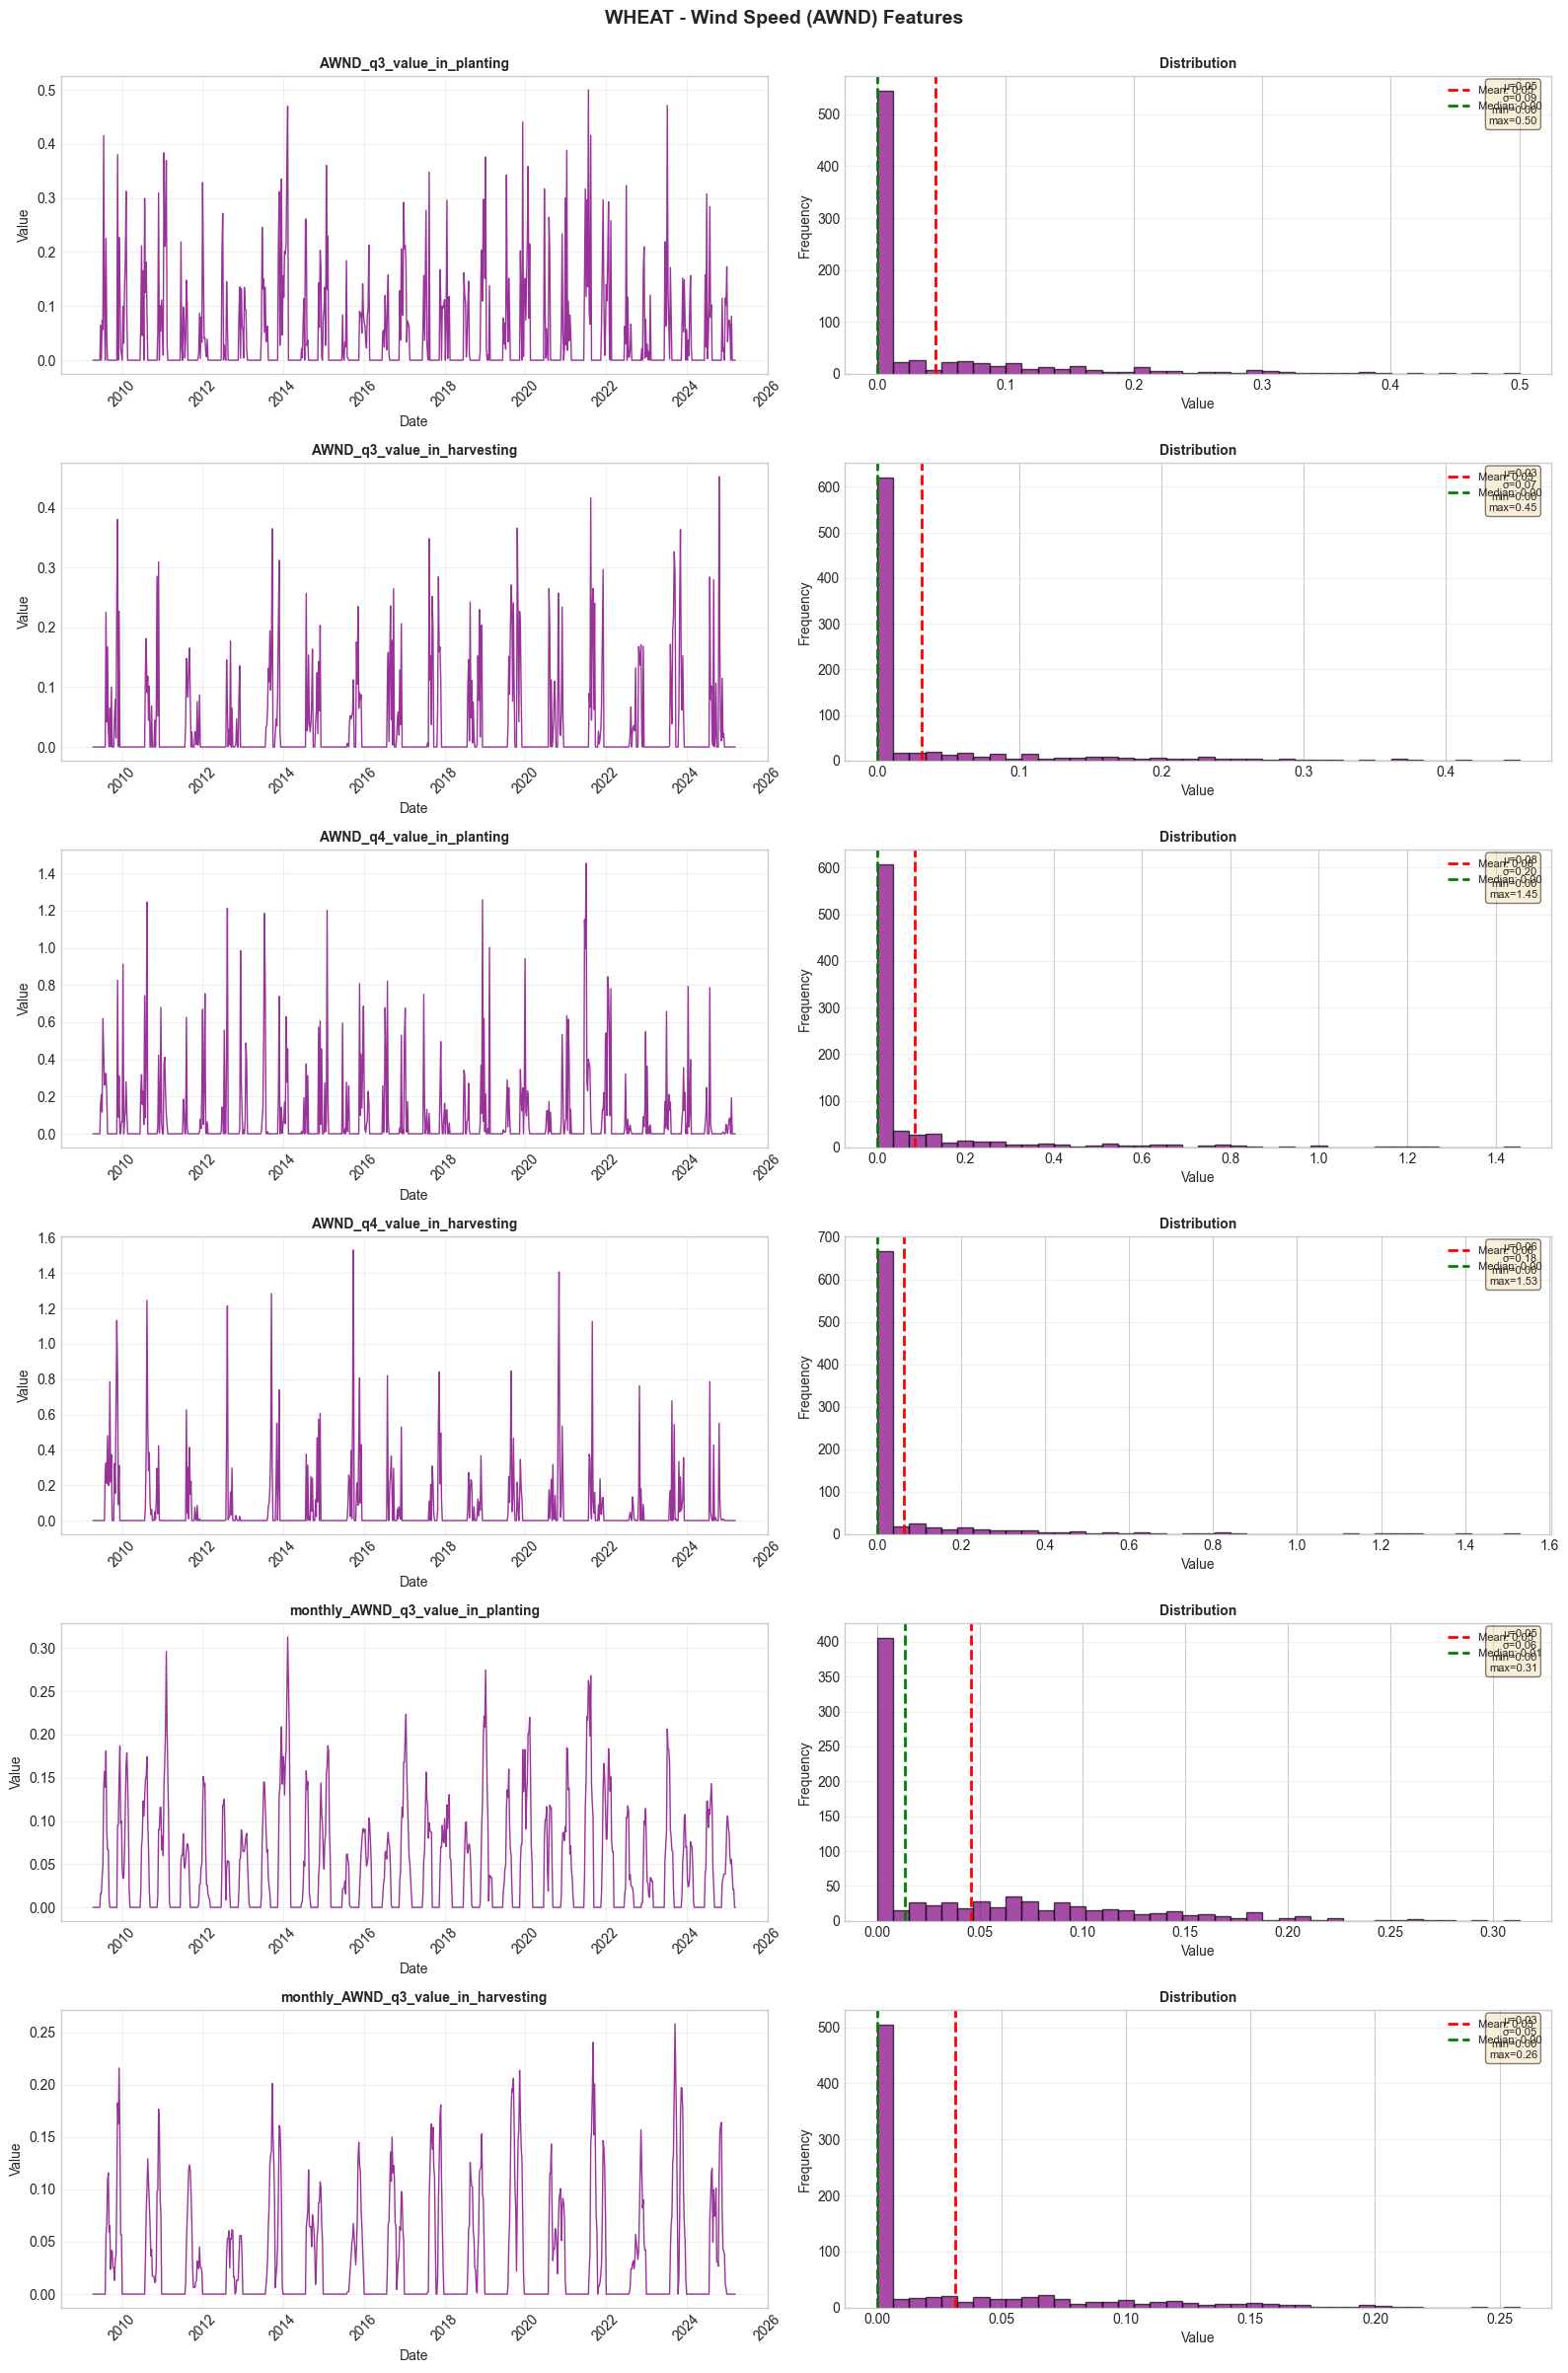

In [83]:
print(f"Plotting {len(awnd_cols)} AWND features (showing first 6)...")
print(f"Features: {awnd_cols[:6]}")

plot_feature_distribution(
    df=df,
    features=awnd_cols,
    title=f'{CROP.upper()} - Wind Speed (AWND) Features',
    color='purple',
    max_features=6
)

### 4.5 Standardized Precipitation Index (SPI) Features

Plotting 2 SPI features...
Features: ['SPI_1m', 'SPI_3m']


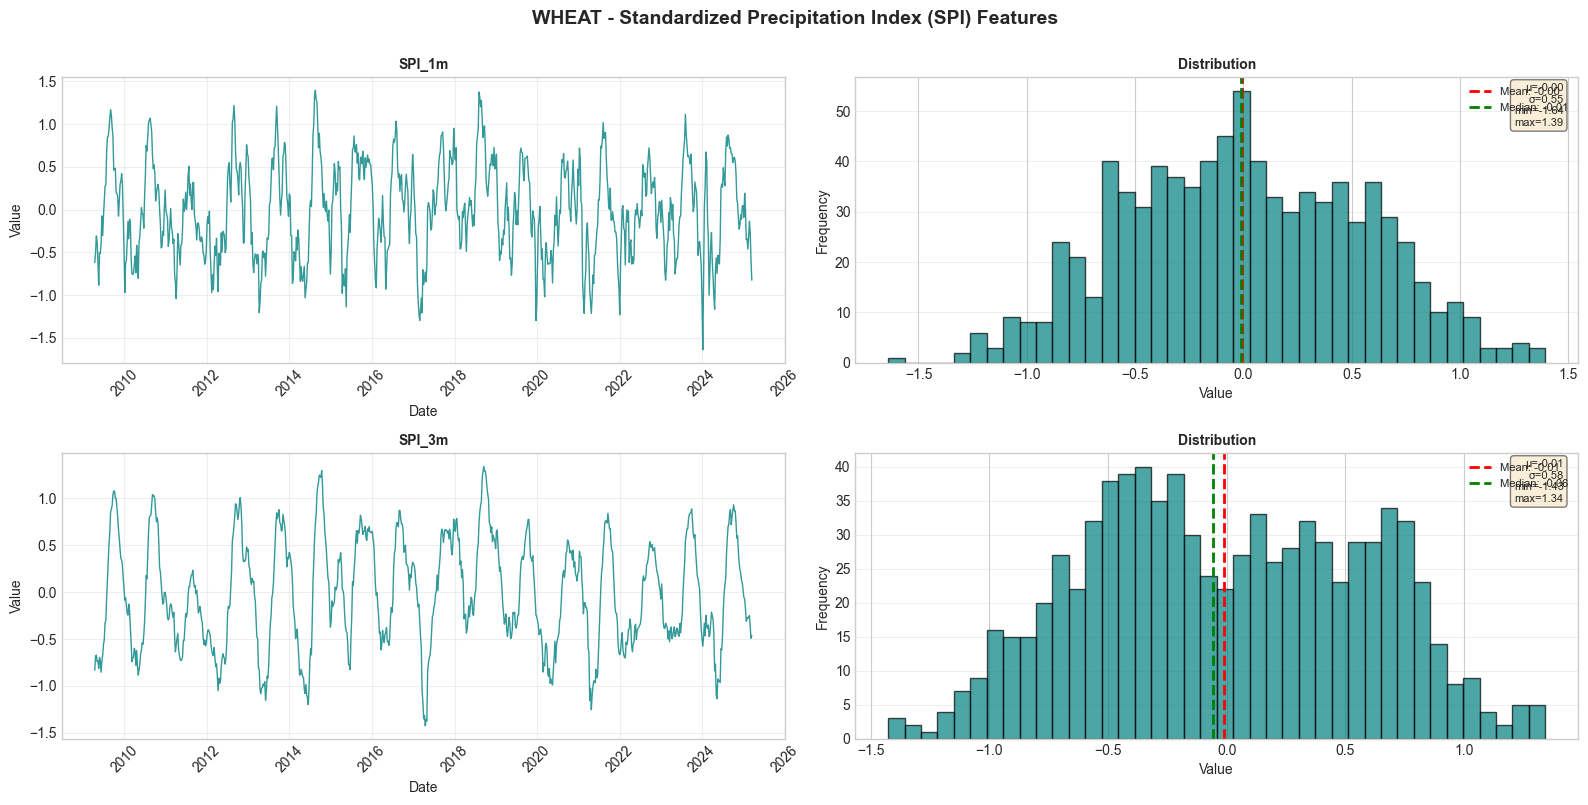

In [82]:
if spi_cols:
    print(f"Plotting {len(spi_cols)} SPI features...")
    print(f"Features: {spi_cols}")
    
    plot_feature_distribution(
        df=df,
        features=spi_cols,
        title=f'{CROP.upper()} - Standardized Precipitation Index (SPI) Features',
        color='teal',
        max_features=len(spi_cols)
    )
else:
    print("No SPI features found in dataset.")

## 5. CO2 Features Analysis

Analysis of CO2 concentration features.

Plotting 3 CO2 features...
Features: ['zscore_co2', 'co2_monthly_mean', 'co2_seasonal_mean']


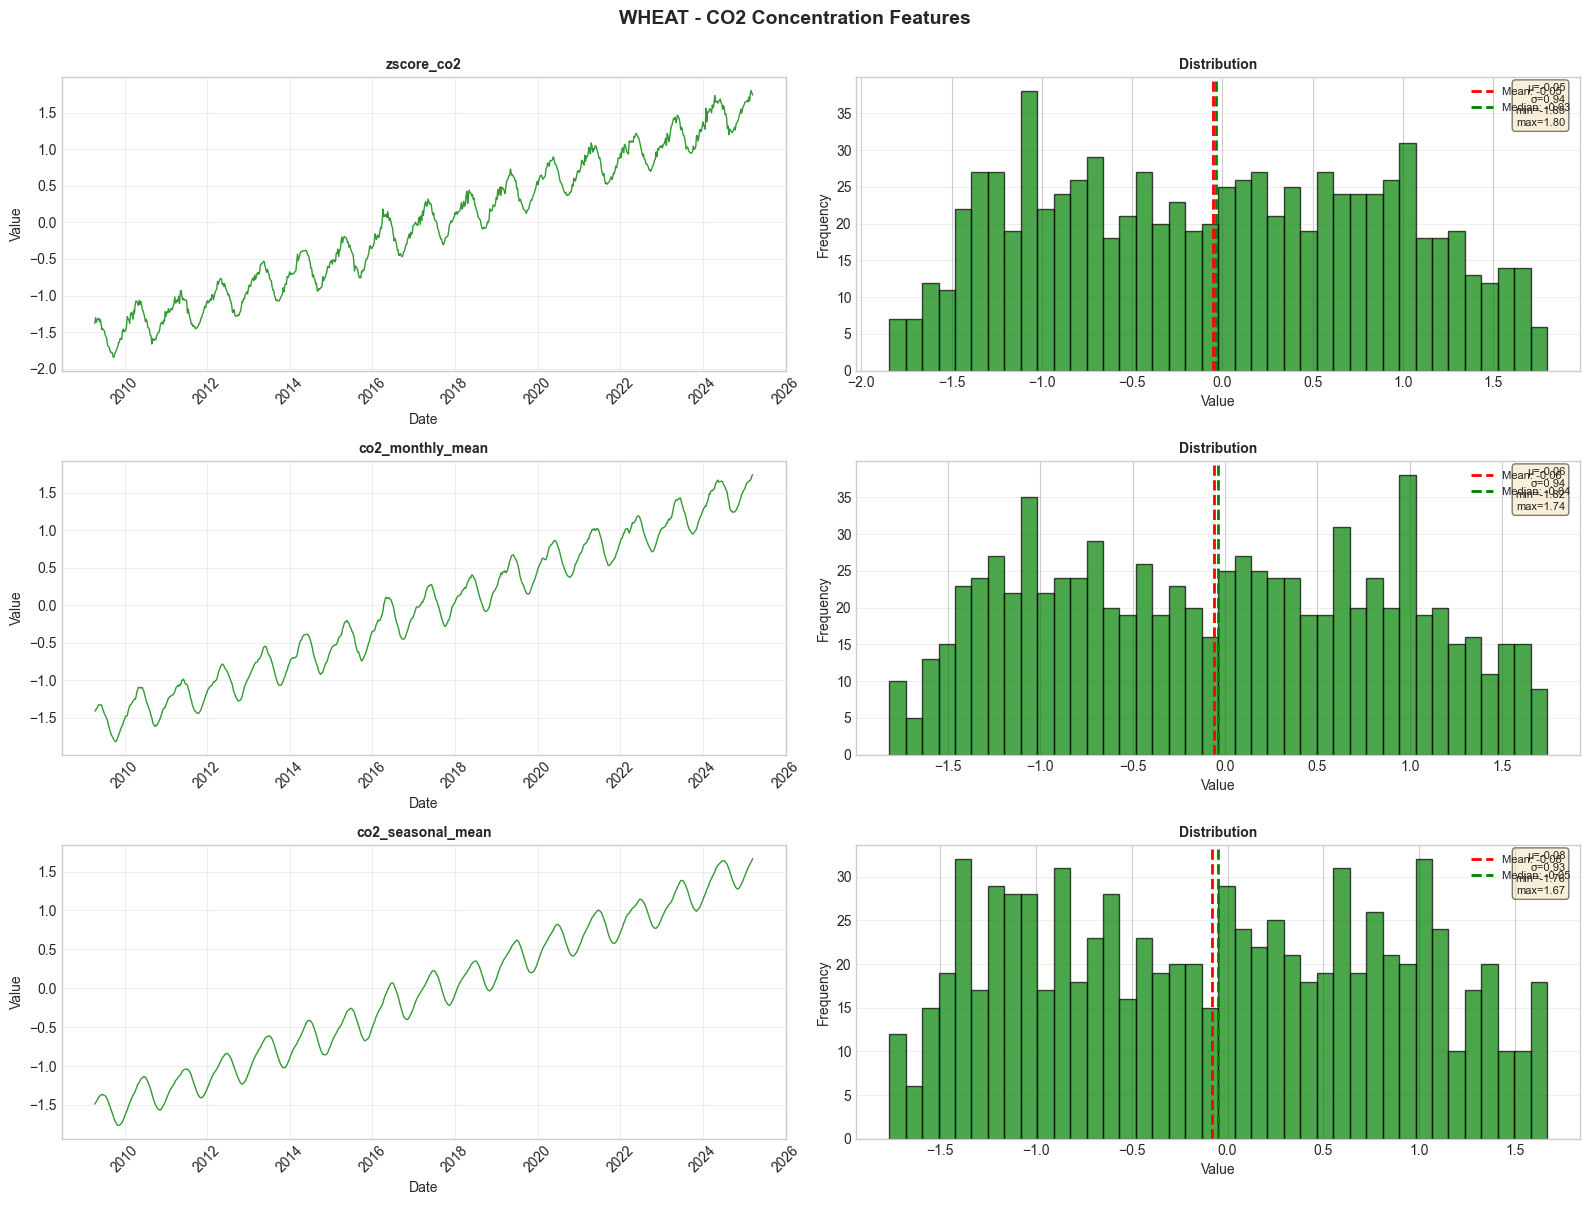

In [81]:
print(f"Plotting {len(co2_cols)} CO2 features...")
print(f"Features: {co2_cols}")

plot_feature_distribution(
    df=df,
    features=co2_cols,
    title=f'{CROP.upper()} - CO2 Concentration Features',
    color='green',
    max_features=len(co2_cols)
)

## 6. PDSI Features Analysis

Analysis of Palmer Drought Severity Index (PDSI) features indicating drought and wetness conditions.

**Feature Categories:**
- `wet`: Wet conditions
- `moderate_wet`: Moderately wet conditions
- `dry`: Dry conditions (drought)
- `moderate_dry`: Moderately dry conditions
- Prefixes: `weekly_`, `monthly_` indicate temporal aggregation

Plotting 12 PDSI features...
Features: ['moderate_wet', 'wet', 'moderate_dry', 'dry', 'monthly_moderate_wet', 'seasonal_moderate_wet', 'monthly_wet', 'seasonal_wet', 'monthly_moderate_dry', 'seasonal_moderate_dry', 'monthly_dry', 'seasonal_dry']


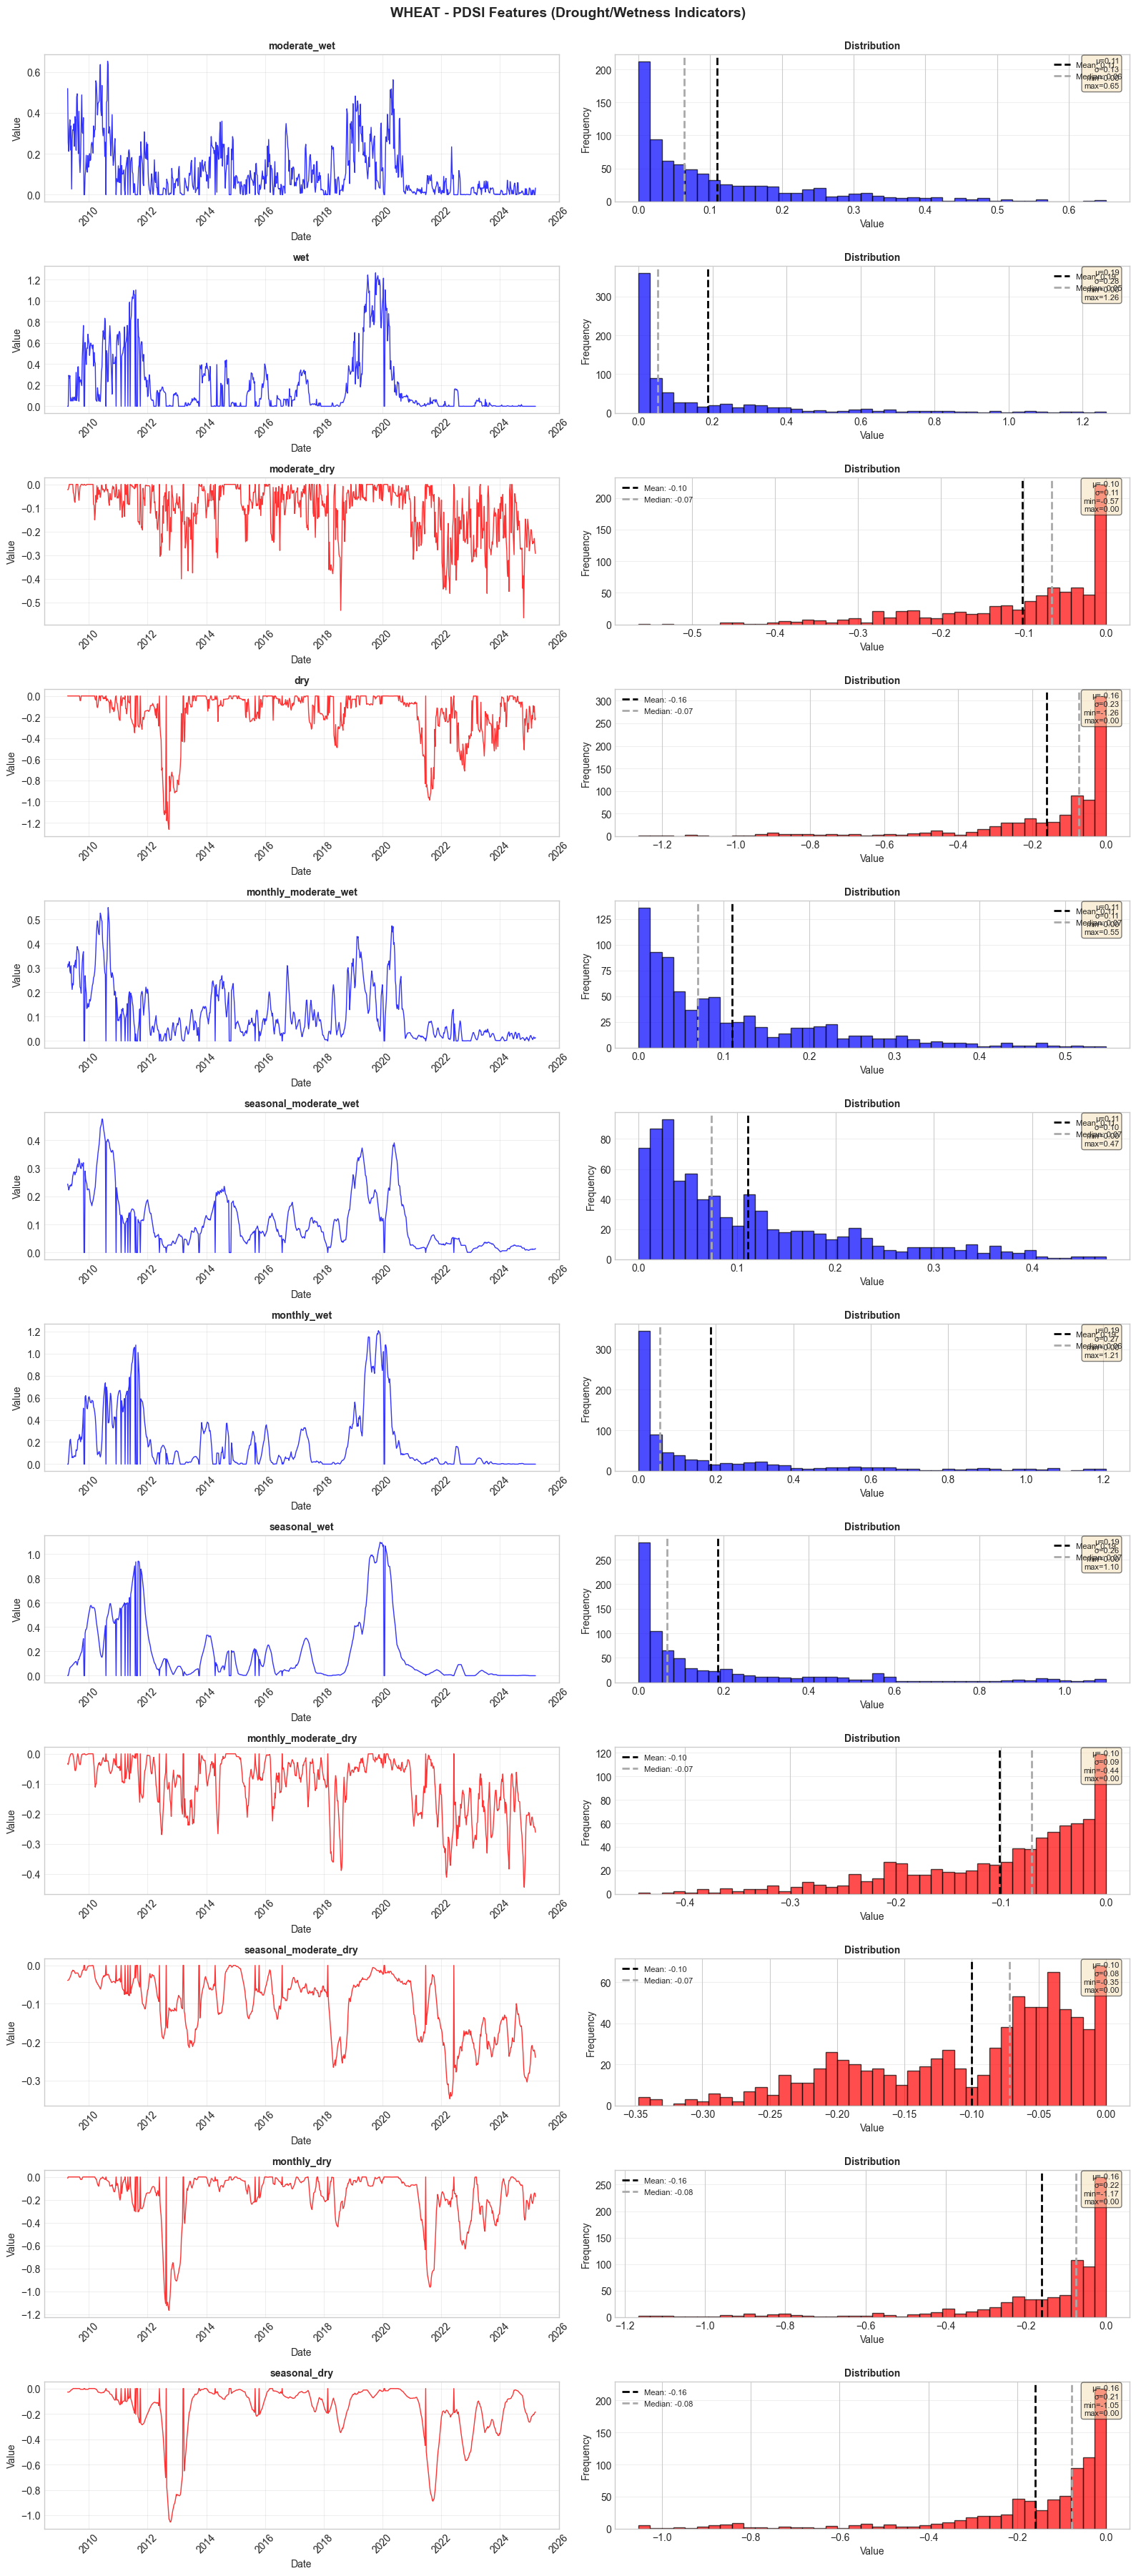

In [80]:
print(f"Plotting {len(pdsi_cols)} PDSI features...")
print(f"Features: {pdsi_cols}")

# Define colors for different PDSI categories
pdsi_colors = {
    'wet': 'blue',
    'moderate_wet': 'lightblue',
    'dry': 'red',
    'moderate_dry': 'orange'
}

# Plot each PDSI feature
n_features = len(pdsi_cols)
fig, axes = plt.subplots(n_features, 2, figsize=(16, 3*n_features))
if n_features == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(pdsi_cols):
    data = df[[col, 'date']].dropna()
    
    # Determine color
    color = 'gray'
    for key, val in pdsi_colors.items():
        if key in col:
            color = val
            break
    
    # Time series
    axes[idx, 0].plot(data['date'], data[col], linewidth=1, alpha=0.8, color=color)
    axes[idx, 0].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx, 0].set_xlabel('Date')
    axes[idx, 0].set_ylabel('Value')
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].tick_params(axis='x', rotation=45)
    
    # Histogram
    axes[idx, 1].hist(data[col], bins=HIST_BINS, edgecolor='black', alpha=HIST_ALPHA, color=color)
    axes[idx, 1].set_title('Distribution', fontsize=10, fontweight='bold')
    axes[idx, 1].set_xlabel('Value')
    axes[idx, 1].set_ylabel('Frequency')
    axes[idx, 1].grid(axis='y', alpha=0.3)
    
    # Statistics
    mean_val = data[col].mean()
    std_val = data[col].std()
    median_val = data[col].median()
    
    axes[idx, 1].axvline(mean_val, color='black', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx, 1].axvline(median_val, color='darkgray', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[idx, 1].legend(fontsize=8)
    
    stats_text = f"μ={mean_val:.2f}\nσ={std_val:.2f}\nmin={data[col].min():.2f}\nmax={data[col].max():.2f}"
    axes[idx, 1].text(0.98, 0.98, stats_text, transform=axes[idx, 1].transAxes,
                     verticalalignment='top', horizontalalignment='right',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=8)

fig.suptitle(f'{CROP.upper()} - PDSI Features (Drought/Wetness Indicators)', fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

## 6. Summary Statistics

In [79]:
# Combine all climate features
all_climate_features = noaa_weather_cols + co2_cols + pdsi_cols

# Calculate summary statistics
summary_stats = df[all_climate_features].describe().T
summary_stats['missing'] = df[all_climate_features].isnull().sum()
summary_stats['missing_pct'] = (summary_stats['missing'] / len(df) * 100).round(2)

print("\n" + "="*100)
print(f"SUMMARY STATISTICS - {CROP.upper()} CLIMATE FEATURES")
print("="*100)
display(summary_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'missing', 'missing_pct']])


SUMMARY STATISTICS - WHEAT CLIMATE FEATURES


,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
TMAX_q3_value_in_planting,832.0,0.063115,0.118215,0.000000,0.000000,0.000000,0.083142,0.758099,0,0.0
TMAX_q3_value_in_harvesting,832.0,0.045680,0.095230,0.000000,0.000000,0.000000,0.045794,0.616147,0,0.0
TMAX_q4_value_in_planting,832.0,0.076476,0.200025,0.000000,0.000000,0.000000,0.033372,1.412560,0,0.0
TMAX_q4_value_in_harvesting,832.0,0.058605,0.168352,0.000000,0.000000,0.000000,0.000094,1.493841,0,0.0
monthly_TMAX_q3_value_in_planting,832.0,0.063115,0.083420,0.000000,0.000000,0.018431,0.115479,0.426633,0,0.0
monthly_TMAX_q3_value_in_harvesting,832.0,0.045680,0.070753,0.000000,0.000000,0.000000,0.082499,0.422631,0,0.0
monthly_TMAX_q4_value_in_planting,832.0,0.076476,0.129371,0.000000,0.000000,0.000220,0.103198,0.746612,0,0.0
monthly_TMAX_q4_value_in_harvesting,832.0,0.058605,0.117385,0.000000,0.000000,0.000000,0.066727,0.828036,0,0.0
seasonal_TMAX_q3_value_in_planting,832.0,0.063063,0.052615,0.000000,0.019325,0.054005,0.101893,0.280235,0,0.0
seasonal_TMAX_q3_value_in_harvesting,832.0,0.045680,0.050304,0.000000,0.000000,0.032196,0.079539,0.244774,0,0.0


### 7.1 Feature Group Summary

In [84]:
print("\n" + "="*80)
print("FEATURE GROUP SUMMARY")
print("="*80)

feature_groups = {
    'NOAA Weather (TMAX)': tmax_cols,
    'NOAA Weather (TMIN)': tmin_cols,
    'NOAA Weather (AWND)': awnd_cols,
    'NOAA Weather (SPI)': spi_cols,
    'CO2 Concentration': co2_cols,
    'PDSI (Drought/Wetness)': pdsi_cols
}

for group_name, cols in feature_groups.items():
    if cols:
        group_data = df[cols]
        print(f"\n{group_name}:")
        print(f"  Number of features: {len(cols)}")
        print(f"  Mean of means: {group_data.mean().mean():.4f}")
        print(f"  Mean of stds: {group_data.std().mean():.4f}")
        print(f"  Total missing: {group_data.isnull().sum().sum()}")
        print(f"  Missing %: {(group_data.isnull().sum().sum() / (len(df) * len(cols)) * 100):.2f}%")

print("\n" + "="*80)


FEATURE GROUP SUMMARY

NOAA Weather (TMAX):
  Number of features: 12
  Mean of means: 0.0609
  Mean of stds: 0.1038
  Total missing: 0
  Missing %: 0.00%

NOAA Weather (TMIN):
  Number of features: 12
  Mean of means: -0.0598
  Mean of stds: 0.1075
  Total missing: 0
  Missing %: 0.00%

NOAA Weather (AWND):
  Number of features: 12
  Mean of means: 0.0562
  Mean of stds: 0.0952
  Total missing: 0
  Missing %: 0.00%

NOAA Weather (SPI):
  Number of features: 2
  Mean of means: -0.0077
  Mean of stds: 0.5644
  Total missing: 0
  Missing %: 0.00%

CO2 Concentration:
  Number of features: 3
  Mean of means: -0.0642
  Mean of stds: 0.9366
  Total missing: 0
  Missing %: 0.00%

PDSI (Drought/Wetness):
  Number of features: 12
  Mean of means: 0.0088
  Mean of stds: 0.1760
  Total missing: 0
  Missing %: 0.00%



## Summary

This notebook analyzed climate features in the dataset:

**NOAA Weather Features:**
- Maximum temperature (TMAX) - extreme heat during planting/harvesting
- Minimum temperature (TMIN) - extreme cold during planting/harvesting
- Wind speed (AWND) - wind conditions
- Standardized Precipitation Index (SPI) - precipitation anomalies

**CO2 Features:**
- CO2 concentration measurements (z-score, weekly mean, monthly mean)

**PDSI Features:**
- Drought and wetness indicators (wet, moderate_wet, dry, moderate_dry)
- Weekly and monthly aggregations

Each feature was visualized with:
- Time series plot showing temporal evolution
- Histogram showing distribution with mean/median lines
- Summary statistics (mean, std, min, max)